# 1) Load Data and Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, f1_score

import cupy as cp
import cudf
from cuml.preprocessing import StandardScaler
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLogisticRegression
from cuml.metrics import accuracy_score

import xgboost as xgb

In [8]:
df = pd.read_csv("sample_to_run_info.csv")

/tmp/ipykernel_939/2515147133.py:1: DtypeWarning: Columns (22,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sample_to_run_info.csv")


In [9]:
abundance = pd.read_csv('species_abundance.csv')

# 2) Exploratory Data Analysis & Cleaning

### Sample metadata (`df`)

In [10]:
# Columns with more than half their values missing are not worth imputing
thresh = int(len(df) * 0.5)
df = df.dropna(axis=1, thresh=thresh)

In [11]:
df.head()

,project_id,sample_name,original_sample_description,run_id,sample_id,second_sample_id,experiment_type,nr_reads_sequenced,instrument_model,disease,phenotype,more,country,collection_date,longitude,latitude
0,PRJDB3418,NaN,APr10S00,DRR028772,DRS020620,SAMD00024580,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
1,PRJDB3418,NaN,APr14S00,DRR028773,DRS020607,SAMD00024581,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
2,PRJDB3418,NaN,APr15S00,DRR028774,DRS020582,SAMD00024582,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
3,PRJDB3418,NaN,APr21S00,DRR028775,DRS020613,SAMD00024583,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN
4,PRJDB3418,NaN,APr24S00,DRR028776,DRS020600,SAMD00024584,AMPLICON,3000.0,454 GS FLX,D006262,Healthy,N,Japan,NaN,NaN,NaN


In [12]:
df = df.drop(['more', 'collection_date', 'longitude', 'latitude', 'sample_name', 'original_sample_description', 'sample_id', 'second_sample_id', 'disease'], axis=1)

In [13]:
df.head()

,project_id,run_id,experiment_type,nr_reads_sequenced,instrument_model,phenotype,country
0,PRJDB3418,DRR028772,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
1,PRJDB3418,DRR028773,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
2,PRJDB3418,DRR028774,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
3,PRJDB3418,DRR028775,AMPLICON,3000.0,454 GS FLX,Healthy,Japan
4,PRJDB3418,DRR028776,AMPLICON,3000.0,454 GS FLX,Healthy,Japan


In [14]:
df['phenotype'].value_counts()

,count
phenotype,
Healthy,48241
Colorectal Neoplasms,5543
Crohn Disease,3516
COVID-19,2911
Parkinson Disease,2169
...,...
Colonic Polyps,5
Urolithiasis,5
Dry Eye Syndromes,4


In [15]:
keep_phenos = [
    "Healthy",
    "Crohn Disease",
    "Colitis, Ulcerative",
]

df = df[df["phenotype"].isin(keep_phenos)].copy()
print(df["phenotype"].value_counts())

phenotype
Healthy                48241
Crohn Disease           3516
Colitis, Ulcerative     1863
Name: count, dtype: int64


In [16]:
# Restrict to projects that actually studied IBD. This keeps only the Healthy samples
# that were collected alongside Crohn or UC cases, so controls come from the same
# cohorts as the cases rather than from unrelated studies.
target_phenotypes = ["Crohn Disease", "Colitis, Ulcerative"]

project_ids = (
    df[df["phenotype"].isin(target_phenotypes)]["project_id"]
    .unique()
)

df = df[df["project_id"].isin(project_ids)].copy()

print(f"Projects with at least one Crohn Disease or Ulcerative Colitis sample: {len(project_ids)}")
print(df["phenotype"].value_counts())

Projects with at least one Crohn Disease or Ulcerative Colitis sample: 46
phenotype
Crohn Disease          3516
Healthy                2099
Colitis, Ulcerative    1863
Name: count, dtype: int64


In [17]:
df['country'].value_counts()

,count
country,
United States of America,3698
China,970
Canada,666
Sweden,637
South Korea,263
Japan,196
Russia,168
Germany,167
India,101


In [18]:
df['experiment_type'].value_counts()

# Amplicon sequencing targets and amplifies specific marker regions via PCR, which
# identifies which microbes are present. Metagenomic (shotgun) sequencing reads all
# genetic material in the sample, giving finer resolution and functional information.

print(pd.crosstab(df['phenotype'], df['experiment_type'], normalize='index'))

# This is the pre-merge picture only. The abundance merge below drops almost all
# amplicon samples, so the modelled data ends up single-technology.

experiment_type      AMPLICON  Metagenomics
phenotype                                  
Colitis, Ulcerative  0.564681      0.435319
Crohn Disease        0.596132      0.403868
Healthy              0.617437      0.382563


In [19]:
# A phenotype confined to one sequencing platform would confound platform effects with
# disease signal. All three appear across the major Illumina platforms, so none is.
ct_counts = pd.crosstab(df['phenotype'], df['instrument_model'])
ct_counts

instrument_model,454 GS,454 GS FLX Titanium,AB 5500 Genetic Analyzer,AB SOLiD 4 System,HiSeq X Ten,Illumina HiSeq 2000,Illumina HiSeq 2500,Illumina HiSeq 4000,Illumina HiSeq X,Illumina MiSeq,Illumina MiniSeq,Illumina NovaSeq 6000,Ion Torrent PGM
phenotype,,,,,,,,,,,,,
"Colitis, Ulcerative",11,60,0,0,25,709,612,0,0,386,23,27,10
Crohn Disease,10,99,15,7,41,1203,845,42,98,840,0,310,6
Healthy,9,97,0,0,15,1105,285,25,0,357,23,173,10


### Species abundance (`abundance`)

In [20]:
abundance.head()

,id,loaded_uid,ncbi_taxon_id,taxon_rank_level,relative_abundance,accession_id
0,1,81104,-1,genus,1.95190,DRR358335
1,2,81104,544,genus,1.07457,DRR358335
2,3,81104,561,genus,0.84957,DRR358335
3,4,81104,570,genus,0.06218,DRR358335
4,5,81104,816,genus,23.29699,DRR358335


In [21]:
abundance['taxon_rank_level'].value_counts()

,count
taxon_rank_level,
genus,2780064
species,2761207


In [22]:
# Species level over genus: finer resolution, and the merge below leaves only shotgun
# data, which supports it. Taxon id -1 is the unassigned bucket.
abund_species = abundance[abundance["taxon_rank_level"] == "species"].copy()
abund_species = abund_species[abund_species["ncbi_taxon_id"] != -1].copy()

In [23]:
# Long to wide: one row per sample, one column per taxon, values are relative
# abundances. Absent taxa become 0.0, which is why the matrix is mostly zeros.
abund_wide = (
    abund_species
    .pivot_table(index="accession_id",      # this matches run_id in df
                 columns="ncbi_taxon_id",
                 values="relative_abundance",
                 aggfunc="sum",
                 fill_value=0.0)
    .reset_index()
)

abund_wide.columns = [
    "run_id" if c == "accession_id" else f"taxon_{int(c)}"
    for c in abund_wide.columns
]

### Merge

The inner join on `run_id` is the most consequential step in the notebook. It keeps
only samples that have an abundance profile, and in doing so drops 46 projects to 12.
Every limitation in Section 9 follows from that number.

In [24]:
merged = df.merge(abund_wide, on="run_id", how="inner")

In [25]:
# The merge is lossy in a way that matters: 46 projects become 12.
matched = df.run_id.isin(abund_wide.run_id)
missing = df[~matched]
print("dropped:", len(missing))
print(missing.experiment_type.value_counts())
print(missing.phenotype.value_counts())
print("projects before:", df.project_id.nunique(), "| after:", merged.project_id.nunique())

dropped: 4640
experiment_type
AMPLICON        4444
Metagenomics     196
Name: count, dtype: int64
phenotype
Crohn Disease          2202
Healthy                1366
Colitis, Ulcerative    1072
Name: count, dtype: int64
projects before: 46 | after: 12


In [26]:
merged.head()

,project_id,run_id,experiment_type,nr_reads_sequenced,instrument_model,phenotype,country,taxon_9,taxon_17,taxon_69,...,taxon_2968459,taxon_2968968,taxon_2969304,taxon_2972461,taxon_2972466,taxon_2972769,taxon_2974552,taxon_2974597,taxon_2975484,taxon_2981769
0,PRJEB76677,ERR13295986,Metagenomics,61317544.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
1,PRJEB76677,ERR13295987,Metagenomics,44948398.0,Illumina HiSeq 2000,Healthy,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.55599
2,PRJEB76677,ERR13295988,Metagenomics,7314392.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
3,PRJEB76677,ERR13295989,Metagenomics,48624378.0,Illumina HiSeq 2000,Healthy,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.45498
4,PRJEB76677,ERR13295990,Metagenomics,61732518.0,Illumina HiSeq 2000,Crohn Disease,Germany,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01691


In [27]:
# Nearly every dropped sample was amplicon, so the surviving set is effectively one
# technology. That settles the amplicon question by accident rather than by design,
# and it is why species-level abundances are appropriate here.
print(merged.experiment_type.value_counts())

experiment_type
Metagenomics    2838
Name: count, dtype: int64


In [28]:
# Split the columns into identifiers/covariates and the taxon features themselves.
META_COLS    = ["project_id", "run_id", "phenotype", "experiment_type",
                "instrument_model", "country", "nr_reads_sequenced"]
FEATURE_COLS = [c for c in merged.columns if c.startswith("taxon_")]

# 3) Labels, Split Diagnostic, & Cross-Validation Setup

Study cohort is the unit that must not leak. Samples from one project share platform,
protocol and population, so a model can score well by recognising the batch rather
than the disease. Grouping on `project_id` makes that impossible.

The diagnostic below shows why a single hold-out cannot be trusted here: it puts 3
projects in test. Cross-validation replaces it so every sample is tested exactly once.

With 12 projects, fold count is a real constraint rather than a default. Too many
folds and a fold holds one project or misses a class; too few and each model trains
on less data. `choose_splitter` searches fold counts and seeds for a geometry where
every class appears in every train and test fold, and reports honestly when no such
geometry exists.

In [29]:
keep_phenos = ["Healthy", "Crohn Disease", "Colitis, Ulcerative"]
# reset_index so positional indices from the CV splitter line up with the frame
df3 = merged[merged["phenotype"].isin(keep_phenos)].copy().reset_index(drop=True)

label_map = {
    "Healthy": 0,
    "Crohn Disease": 1,
    "Colitis, Ulcerative": 2,
}
df3["label"] = df3["phenotype"].map(label_map)

taxon_cols = [c for c in df3.columns if c.startswith("taxon_")]
print("samples:", len(df3), "| taxa:", len(taxon_cols), "| projects:", df3.project_id.nunique())

samples: 2838 | taxa: 2893 | projects: 12


In [30]:
# How thin one grouped hold-out really is. Printing raw counts rather than
# proportions makes the support behind each metric visible.
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df3, df3["label"], groups=df3["project_id"]))
df_train, df_test = df3.iloc[train_idx], df3.iloc[test_idx]

print(df_train.project_id.nunique(), "train |", df_test.project_id.nunique(), "test")
print(df_test.label.value_counts())

9 train | 3 test
label
1    130
0     43
2     27
Name: count, dtype: int64


In [31]:
# Cross-validation setup. This replaces the single split above.
# StratifiedGroupKFold keeps whole projects together (no cohort leakage) while
# balancing labels across folds, so every sample is tested exactly once.
from sklearn.model_selection import StratifiedGroupKFold

groups = df3["project_id"].to_numpy()
y_all  = df3["label"].to_numpy()


def fold_problems(splitter, frame, y, grp, min_train_frac=0.4, min_class_count=10):
    """Return a list of reasons this fold geometry is unusable ([] means it's fine).

    StratifiedGroupKFold balances LABELS but not SAMPLE COUNTS, and when a class
    lives in only a few projects it cannot keep that class in every fold at all.
    Two distinct failure modes, both seen in this dataset:

      * class missing from a fold's TEST set  -> that fold's AUC is undefined
      * class missing from a fold's TRAIN set -> the model cannot be fit at all
        (cuML raises "loss='sigmoid' requires n_classes == 2 (got 1)")

    A fold that trains on a sliver is a third, quieter failure: at 5 folds one fold
    trained on 438 samples and produced predictions for 2400.
    """
    n = len(frame)
    classes = set(np.unique(y).tolist())
    problems = []

    for f, (tr, te) in enumerate(splitter.split(frame, y, grp)):
        missing_tr = sorted(classes - set(np.unique(y[tr]).tolist()))
        if missing_tr:
            problems.append(f"fold {f}: TRAIN missing class(es) {missing_tr} — cannot fit")

        counts = pd.Series(y[te]).value_counts().to_dict()
        thin = [int(c) for c in sorted(classes) if counts.get(c, 0) < min_class_count]
        if thin:
            problems.append(f"fold {f}: TEST has <{min_class_count} samples of class(es) {thin}")

        if len(tr) < min_train_frac * n:
            problems.append(f"fold {f}: trains on only {len(tr)}/{n} ({len(tr)/n:.0%})")

    return problems


def show_fold_geometry(splitter, frame, y, grp, title=""):
    """Print each fold's shape and any problems found."""
    if title:
        print(f"=== {title} ===")
    for f, (tr, te) in enumerate(splitter.split(frame, y, grp)):
        counts = pd.Series(y[te]).value_counts().sort_index().to_dict()
        print(f"fold {f}: {len(tr):4d} train / {len(te):4d} test | "
              f"test projects={frame.iloc[te]['project_id'].nunique()} | test counts={counts}")
    problems = fold_problems(splitter, frame, y, grp)
    if problems:
        print("!! DEGENERATE FOLDS — scores below are not interpretable:")
        for p in problems:
            print("   -", p)
    else:
        print("Fold geometry OK: all classes present in every train and test fold.")
    return problems


def choose_splitter(frame, y, grp, n_splits_options=(3, 2), seeds=(42, 0, 1, 7, 13, 2024)):
    """Pick the first (n_splits, seed) whose folds are all usable.

    With 12 projects and a class concentrated in a few of them, not every setting
    yields a workable split — so search instead of hard-coding one and hoping.
    """
    best, best_problems = None, None
    for ns in n_splits_options:
        for s in seeds:
            sp = StratifiedGroupKFold(n_splits=ns, shuffle=True, random_state=s)
            problems = fold_problems(sp, frame, y, grp)
            if not problems:
                print(f"selected n_splits={ns}, random_state={s} (clean geometry)")
                return sp
            if best is None or len(problems) < len(best_problems):
                best, best_problems = (sp, ns, s), problems
    sp, ns, s = best
    print(f"WARNING: no fully clean geometry found. Using the least-bad option "
          f"(n_splits={ns}, random_state={s}) with {len(best_problems)} problem(s).")
    return sp


# Fold geometry matters more than usual here. 5 folds over ~12 projects gave folds
# folds missing a class entirely, and one fold training on 15% of the data. Fewer folds
# means more projects per fold; we search for a setting that is actually usable.
sgkf = choose_splitter(df3, y_all, groups)
N_SPLITS = sgkf.get_n_splits()
_ = show_fold_geometry(sgkf, df3, y_all, groups, "multiclass fold geometry")


def grouped_val_split(train_idx, y, grp, val_frac=0.25, seed=42):
    """Carve a group-disjoint validation set out of a fold's training indices.

    Used for XGBoost early stopping and threshold tuning so the held-out test
    fold is never consulted during training/tuning. Falls back to a stratified
    non-grouped split if the grouped one would leave a class out of validation.
    """
    gss_inner = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=seed)
    inner, val = next(gss_inner.split(train_idx, y[train_idx], grp[train_idx]))
    inner_idx, val_idx = train_idx[inner], train_idx[val]

    # Threshold tuning and early stopping both need both classes on each side.
    n_classes = len(np.unique(y[train_idx]))
    if len(np.unique(y[inner_idx])) < n_classes or len(np.unique(y[val_idx])) < n_classes:
        rng = np.random.default_rng(seed)
        perm = rng.permutation(len(train_idx))
        cut = int(len(train_idx) * (1 - val_frac))
        inner_idx, val_idx = train_idx[perm[:cut]], train_idx[perm[cut:]]
        print("   note: grouped validation split left a class empty; "
              "fell back to a random (non-grouped) validation split for this fold.")
    return inner_idx, val_idx

=== multiclass fold geometry ===
fold 0: 2712 train /  126 test | test projects=2 | test counts={0: 48, 1: 19, 2: 59}
fold 1: 1932 train /  906 test | test projects=1 | test counts={0: 142, 1: 462, 2: 302}
fold 2: 1032 train / 1806 test | test projects=9 | test counts={0: 543, 1: 833, 2: 430}
!! DEGENERATE FOLDS — scores below are not interpretable:
   - fold 2: trains on only 1032/2838 (36%)


In [32]:
def require_scored(res_dict, name="this CV"):
    """Return the `scored` mask, failing with a readable explanation if it is empty.

    Every fold being skipped is a real possibility here, not a coding slip: it means
    the minority class is confined to so few projects that grouped CV cannot leave
    any of it in a training fold. Better to say that plainly than to let the report
    cells die on empty arrays.
    """
    m = res_dict["scored"]
    if not m.any():
        raise RuntimeError(
            f"No samples in {name} were scored — every fold had a single-class "
            "training set. The minority class is confined to too few projects for "
            "grouped cross-validation to work at any fold count. See the "
            "project x label crosstab in Section 8; this is a data limitation, "
            "not a bug to fix in code."
        )
    return m

# 4) Feature Selection (LASSO)

L1 logistic regression drives most coefficients to exactly zero, so the surviving
taxa are the selected ones. This runs inside each fold on that fold's training rows
only. Selecting features once on all data would let the held-out projects influence
which features exist, which is the same leak as tuning on test.

In [33]:
def select_features(X_tr, y_tr, C=0.1):
    """Fit L1 logistic regression on training rows; return taxa with any non-zero coef.

    X_tr : 2D numpy array of abundances for the training rows, columns in
           `taxon_cols` order. Already feature-transformed by the caller when a
           transform is in use — LASSO is sensitive to the transform even though
           the tree models are not, so it must see the same representation.
    y_tr : integer labels for those rows. Must contain at least two classes;
           cuML raises "loss='sigmoid' requires n_classes == 2 (got 1)" otherwise,
           which is why the CV loops skip single-class training folds.
    """
    scaler = StandardScaler(with_mean=False)
    X_tr_scaled = scaler.fit_transform(cudf.DataFrame(X_tr, columns=taxon_cols))

    clf = cuLogisticRegression(
        penalty="l1",
        C=C,                   # controls sparsity
        l1_ratio=None,         # pure L1
        fit_intercept=True,
        class_weight="balanced",
        max_iter=5000,
        solver="qn",
        verbose=0,
    )
    clf.fit(X_tr_scaled, cudf.Series(y_tr))

    coefs = clf.coef_.to_pandas().to_numpy()   # (n_classes, n_features)
    nz_any = (coefs != 0).any(axis=0)          # keep taxa non-zero for any class
    return list(np.array(taxon_cols)[nz_any])

# 5) Cross-Validated Multiclass Evaluation

One pass over the folds. Each fold selects its own features, carves a grouped
validation set for early stopping, trains both models, and predicts the held-out
projects once. Pooling the per-fold predictions gives one out-of-fold prediction per
sample.

Two things are compared here beyond the models themselves: three feature transforms,
and class weighting as a lever on UC recall.

In [34]:
import inspect

_RF_KW = dict(n_estimators=300, max_depth=20, max_features=1.0,
              n_bins=16, bootstrap=True, random_state=42)

# Not every cuML build exposes class_weight on the RF; detect instead of assuming.
_RF_SUPPORTS_CW = "class_weight" in inspect.signature(cuRF.__init__).parameters
if not _RF_SUPPORTS_CW:
    print("note: this cuML build's RandomForestClassifier has no class_weight; "
          "RF will run unweighted (XGBoost still uses sample weights).")


def make_rf(balance=False):
    if balance and _RF_SUPPORTS_CW:
        return cuRF(class_weight="balanced", **_RF_KW)
    return cuRF(**_RF_KW)


def balanced_weights(y):
    """Per-sample weights inversely proportional to class frequency.

    XGBoost's multi:softprob has no class_weight, so we pass weights on the DMatrix.
    This is the multiclass equivalent of class_weight='balanced'.
    """
    classes, counts = np.unique(y, return_counts=True)
    freq = dict(zip(classes, counts))
    return np.array([len(y) / (len(classes) * freq[v]) for v in y], dtype=float)


def run_multiclass_cv(transform=None, label="raw", balance=False):
    """Grouped CV (N_SPLITS folds) for the 3-class problem.

    transform : row-wise feature transform (np.log1p, clr, ...), applied BEFORE
        feature selection so the whole pipeline sees one representation. These
        transforms use no cross-sample statistics, so transforming the full matrix
        up front is NOT leakage (unlike, say, a StandardScaler fit on all rows).
    balance : weight classes inversely to frequency, to lift minority-class recall.

    Returns out-of-fold predictions plus a `scored` mask marking which samples
    actually received a prediction (a fold with a single-class training set is
    skipped, so its samples are left unscored rather than silently counted wrong).
    """
    X_full = df3[taxon_cols].to_numpy()
    if transform is not None:
        X_full = transform(X_full)
    pos = {c: i for i, c in enumerate(taxon_cols)}

    n = len(df3)
    oof_pred_rf   = np.full(n, -1)
    oof_pred_xgb  = np.full(n, -1)
    oof_proba_xgb = np.zeros((n, 3))
    scored        = np.zeros(n, dtype=bool)
    rf_acc, xgb_acc, xgb_auc = [], [], []

    for fold_i, (tr, te) in enumerate(sgkf.split(df3, y_all, groups)):
        # A classifier needs at least two classes in training; skip rather than crash.
        if len(np.unique(y_all[tr])) < 2:
            print(f"   [{label}] skipping fold {fold_i}: training set has a single class; "
                  f"its {len(te)} test samples are left unscored.")
            continue

        # (1) feature selection on the TRANSFORMED training rows only
        feats = select_features(X_full[tr], y_all[tr])
        fp = [pos[f] for f in feats]

        # (2) grouped validation carve-out for XGBoost early stopping
        inner, val = grouped_val_split(tr, y_all, groups)

        X_tr    = X_full[np.ix_(tr, fp)]
        X_inner = X_full[np.ix_(inner, fp)]
        X_val   = X_full[np.ix_(val, fp)]
        X_te    = X_full[np.ix_(te, fp)]
        y_te = y_all[te]

        # (3) Random Forest trains on the full fold-train, no early stopping needed
        rf = make_rf(balance)
        rf.fit(cudf.DataFrame(X_tr, columns=feats), cudf.Series(y_all[tr]))
        pred_rf = rf.predict(cudf.DataFrame(X_te, columns=feats)).to_numpy().astype(int)
        oof_pred_rf[te] = pred_rf
        rf_acc.append((pred_rf == y_te).mean())

        # (4) XGBoost early-stops on the grouped validation set, never on test
        dtrain = xgb.DMatrix(X_inner, label=y_all[inner],
                             weight=balanced_weights(y_all[inner]) if balance else None)
        dval   = xgb.DMatrix(X_val, label=y_all[val],
                             weight=balanced_weights(y_all[val]) if balance else None)
        dtest  = xgb.DMatrix(X_te, label=y_te)
        params = {
            "objective": "multi:softprob", "num_class": 3,
            "tree_method": "hist", "max_depth": 6, "eta": 0.1,
            "subsample": 0.8, "colsample_bytree": 0.8,
            "eval_metric": "mlogloss", "device": "cuda",
        }
        bst = xgb.train(params, dtrain, num_boost_round=300,
                        evals=[(dval, "val")], early_stopping_rounds=30,
                        verbose_eval=False)

        # (5) predict the held-out fold once
        proba = bst.predict(dtest)
        oof_proba_xgb[te] = proba
        pred_xgb = proba.argmax(axis=1)
        oof_pred_xgb[te] = pred_xgb
        scored[te] = True
        xgb_acc.append((pred_xgb == y_te).mean())
        if len(np.unique(y_te)) == 3:
            xgb_auc.append(roc_auc_score(np.eye(3)[y_te], proba, multi_class="ovr"))
        else:
            xgb_auc.append(np.nan)   # AUC undefined when a class is absent from test

    def ms(a):
        return f"{np.nanmean(a):.3f} ± {np.nanstd(a):.3f}" if len(a) else "n/a"
    print(f"[{label}] RF  accuracy {ms(rf_acc)}")
    print(f"[{label}] XGB accuracy {ms(xgb_acc)} | macro ROC-AUC {ms(xgb_auc)}")
    if not scored.all():
        print(f"[{label}] WARNING: {(~scored).sum()}/{n} samples unscored (skipped folds).")

    return {
        "oof_pred_rf": oof_pred_rf, "oof_pred_xgb": oof_pred_xgb,
        "oof_proba_xgb": oof_proba_xgb, "scored": scored,
        "rf_acc": rf_acc, "xgb_acc": xgb_acc, "xgb_auc": xgb_auc,
    }

note: this cuML build's RandomForestClassifier has no class_weight; RF will run unweighted (XGBoost still uses sample weights).


In [35]:
# Tree ensembles split on thresholds, so they are invariant to any monotonic
# per-feature transform: log1p cannot change a Random Forest or XGBoost by
# construction. It can only act through LASSO selection, which is why the transform
# is applied before select_features rather than after.
#
# CLR divides each taxon by its sample's geometric mean. Because it mixes information
# across taxa it is not a per-feature monotonic map, so unlike log1p it can move the
# trees themselves. It is included as the transform that is actually able to differ.
def clr(X, pseudocount=1e-6):
    """Centered log-ratio transform for compositional (relative abundance) rows."""
    Xp = np.asarray(X, dtype=float) + pseudocount
    log_Xp = np.log(Xp)
    return log_Xp - log_Xp.mean(axis=1, keepdims=True)


res_raw   = run_multiclass_cv(transform=None,     label="raw")
res_log1p = run_multiclass_cv(transform=np.log1p, label="log1p")
res_clr   = run_multiclass_cv(transform=clr,      label="clr")

# All three land within one per-fold standard deviation of each other, so none of them
# helps. BEST_TRANSFORM feeds the Section 6 refit, so keep it in sync with `res`.
res            = res_raw
BEST_TRANSFORM = None

   note: grouped validation split left a class empty; fell back to a random (non-grouped) validation split for this fold.
[raw] RF  accuracy 0.495 ± 0.041
[raw] XGB accuracy 0.453 ± 0.048 | macro ROC-AUC 0.705 ± 0.071
   note: grouped validation split left a class empty; fell back to a random (non-grouped) validation split for this fold.
[log1p] RF  accuracy 0.501 ± 0.034
[log1p] XGB accuracy 0.450 ± 0.031 | macro ROC-AUC 0.713 ± 0.066
   note: grouped validation split left a class empty; fell back to a random (non-grouped) validation split for this fold.
[clr] RF  accuracy 0.472 ± 0.045
[clr] XGB accuracy 0.440 ± 0.016 | macro ROC-AUC 0.684 ± 0.027


In [36]:
# `scored` excludes samples from any skipped fold. Counting them would treat a missing
# prediction as a wrong one.
target_names = ["Healthy", "Crohn", "UC"]
m = require_scored(res, "the multiclass CV")
if not m.all():
    print(f"NOTE: reporting on {m.sum()}/{len(m)} samples; the rest were in skipped folds.\n")

print("Random Forest — out-of-fold")
print(classification_report(y_all[m], res["oof_pred_rf"][m], target_names=target_names))

print("XGBoost — out-of-fold")
print(classification_report(y_all[m], res["oof_pred_xgb"][m], target_names=target_names))
if len(np.unique(y_all[m])) == 3:
    print("XGBoost macro ROC-AUC (OOF):",
          roc_auc_score(np.eye(3)[y_all[m]], res["oof_proba_xgb"][m], multi_class="ovr"))
else:
    print("Macro ROC-AUC skipped: not all three classes are present among scored samples.")

Random Forest — out-of-fold
              precision    recall  f1-score   support

     Healthy       0.49      0.29      0.36       733
       Crohn       0.59      0.56      0.57      1314
          UC       0.33      0.48      0.39       791

    accuracy                           0.47      2838
   macro avg       0.47      0.44      0.44      2838
weighted avg       0.49      0.47      0.47      2838

XGBoost — out-of-fold
              precision    recall  f1-score   support

     Healthy       0.47      0.36      0.41       733
       Crohn       0.62      0.39      0.48      1314
          UC       0.33      0.60      0.43       791

    accuracy                           0.44      2838
   macro avg       0.47      0.45      0.44      2838
weighted avg       0.50      0.44      0.44      2838

XGBoost macro ROC-AUC (OOF): 0.6463409545731436


In [37]:
# UC is the minority class and the hardest to separate from Crohn, so it carries the
# weakest recall. Class weighting is the cheapest lever available.
#
# If the RF row below is identical weighted and unweighted, this cuML build is
# ignoring class_weight; XGBoost still gets sample weights either way.
from sklearn.metrics import recall_score

res_bal = run_multiclass_cv(transform=None, label="raw+balanced", balance=True)


def per_class_recall(r, key):
    mask = r["scored"]
    return recall_score(y_all[mask], r[key][mask],
                        labels=[0, 1, 2], average=None, zero_division=0)


print("\nrecall per class [Healthy, Crohn, UC] — UC is the number to watch:")
for name, r in [("unweighted", res_raw), ("balanced", res_bal)]:
    print(f"  {name:>10} | RF  {per_class_recall(r, 'oof_pred_rf').round(3)}"
          f" | XGB {per_class_recall(r, 'oof_pred_xgb').round(3)}")

# Weighting redistributes a decision boundary; it cannot create signal that is absent.

   note: grouped validation split left a class empty; fell back to a random (non-grouped) validation split for this fold.
[raw+balanced] RF  accuracy 0.495 ± 0.041
[raw+balanced] XGB accuracy 0.512 ± 0.112 | macro ROC-AUC 0.715 ± 0.090

recall per class [Healthy, Crohn, UC] — UC is the number to watch:
  unweighted | RF  [0.288 0.556 0.484] | XGB [0.363 0.385 0.604]
    balanced | RF  [0.288 0.556 0.484] | XGB [0.404 0.365 0.651]


# 6) Feature Importances

Performance is measured by cross-validation above. Ranking taxa is a different
question, so it uses a separate full-data refit. Nothing is held out here, which
means these rankings are hypothesis-generating and carry no performance claim.

In [38]:
# Ranking taxa only. No hold-out here, so nothing about accuracy can be read from it.
# BEST_TRANSFORM keeps this on the same representation the reported scores came from.
X_taxa = df3[taxon_cols].to_numpy()
if BEST_TRANSFORM is not None:
    X_taxa = BEST_TRANSFORM(X_taxa)

all_feats = select_features(X_taxa, y_all)
print("Features selected on full data:", len(all_feats))

pos_all = {c: i for i, c in enumerate(taxon_cols)}
X_all_sel = X_taxa[:, [pos_all[f] for f in all_feats]]

rf_full = cuRF(**_RF_KW)
rf_full.fit(cudf.DataFrame(X_all_sel, columns=all_feats), cudf.Series(y_all))

dall = xgb.DMatrix(X_all_sel, label=y_all, feature_names=all_feats)
params_full = {
    "objective": "multi:softprob", "num_class": 3, "tree_method": "hist",
    "max_depth": 6, "eta": 0.1, "subsample": 0.8, "colsample_bytree": 0.8,
    "eval_metric": "mlogloss", "device": "cuda",
}
bst_full = xgb.train(params_full, dall, num_boost_round=200)

Features selected on full data: 746


In [39]:
# Mean impurity decrease: how much each taxon reduces class mixing at its splits.
importances = np.asarray(rf_full.feature_importances_)
idx = importances.argsort()[::-1][:30]
rf_imp_df = pd.DataFrame({
    "taxon": np.array(all_feats)[idx],
    "rf_importance": importances[idx],
})
print(rf_imp_df)

            taxon  rf_importance
0   taxon_2485925       0.034758
1   taxon_2981769       0.034030
2    taxon_745368       0.027291
3       taxon_853       0.021880
4    taxon_328814       0.019548
5     taxon_39486       0.019192
6     taxon_28118       0.018193
7    taxon_371601       0.015776
8   taxon_2885350       0.014940
9   taxon_2929491       0.014402
10  taxon_2293035       0.009855
11  taxon_2292182       0.009374
12      taxon_821       0.008937
13   taxon_338188       0.008834
14      taxon_820       0.008715
15  taxon_2292190       0.008691
16   taxon_871665       0.008636
17    taxon_33038       0.008631
18  taxon_1912855       0.008278
19    taxon_33039       0.007734
20    taxon_39488       0.007703
21  taxon_1150298       0.007588
22    taxon_28117       0.007507
23    taxon_47678       0.007292
24     taxon_1680       0.007111
25  taxon_1720194       0.007040
26   taxon_360807       0.006855
27    taxon_40545       0.006791
28   taxon_165179       0.006773
29    taxo

In [40]:
# Gain: average loss improvement contributed by splits on each taxon.
gain = bst_full.get_score(importance_type="gain")
xgb_imp_df = (
    pd.DataFrame(gain.items(), columns=["taxon", "gain"])
      .sort_values("gain", ascending=False)
      .head(30)
      .reset_index(drop=True)
)
print(xgb_imp_df)

            taxon       gain
0   taxon_1750560  12.515688
1    taxon_163665  10.493678
2    taxon_745368   7.645354
3     taxon_44742   6.824785
4   taxon_1411144   6.613184
5   taxon_2763670   6.494215
6   taxon_1965542   6.128716
7   taxon_1944635   6.100989
8   taxon_2763061   5.735433
9   taxon_2485925   5.680767
10  taxon_2292190   5.542767
11  taxon_2763671   5.276887
12    taxon_54005   5.227819
13  taxon_2293138   5.128087
14  taxon_2606708   5.090411
15  taxon_2086583   5.059481
16   taxon_328814   4.770502
17  taxon_1673720   4.710666
18  taxon_1217282   4.618707
19  taxon_2830658   4.436574
20   taxon_187979   4.153012
21  taxon_2015901   4.102759
22  taxon_2547410   4.029939
23    taxon_39486   4.001405
24     taxon_2173   3.960739
25  taxon_1287640   3.798402
26  taxon_2049049   3.783905
27      taxon_853   3.752632
28  taxon_2292211   3.705290
29  taxon_1506471   3.674495


# 7) Out-of-Fold Confusion Matrices

Pooled across folds, so each sample appears once and none was seen during its own
training. The off-diagonal cells are the interesting part: they show which pairs of
conditions the models actually confuse.

In [41]:
class_names = ["Healthy", "Crohn", "UC"]

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(title)
    print(classification_report(y_true, y_pred, target_names=class_names))

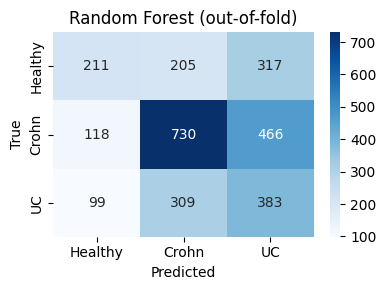

Random Forest (out-of-fold)
              precision    recall  f1-score   support

     Healthy       0.49      0.29      0.36       733
       Crohn       0.59      0.56      0.57      1314
          UC       0.33      0.48      0.39       791

    accuracy                           0.47      2838
   macro avg       0.47      0.44      0.44      2838
weighted avg       0.49      0.47      0.47      2838



In [42]:
m = res["scored"]
plot_cm(y_all[m], res["oof_pred_rf"][m], "Random Forest (out-of-fold)")

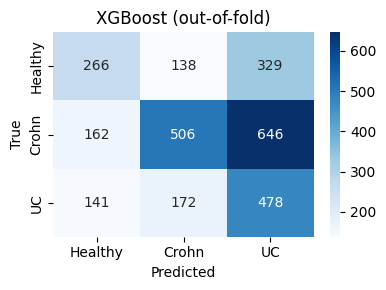

XGBoost (out-of-fold)
              precision    recall  f1-score   support

     Healthy       0.47      0.36      0.41       733
       Crohn       0.62      0.39      0.48      1314
          UC       0.33      0.60      0.43       791

    accuracy                           0.44      2838
   macro avg       0.47      0.45      0.44      2838
weighted avg       0.50      0.44      0.44      2838



In [43]:
m = res["scored"]
plot_cm(y_all[m], res["oof_pred_xgb"][m], "XGBoost (out-of-fold)")

# 8) Binary Classification: Crohn vs Ulcerative Colitis

Healthy samples excluded, leaving 0 = Crohn, 1 = UC.

This problem gets its own geometry search rather than reusing the multiclass one. UC
appears in 7 of 12 projects, a different distribution from the 3-class labels, so a
fold count that works there can still strand a binary fold with no UC to learn from.
The search settles on 2 folds, which is the only clean geometry available.

The decision threshold matters because the classes are imbalanced. It is tuned on the
validation split, never on test.

In [44]:
ibd_mask = df3["phenotype"].isin(["Crohn Disease", "Colitis, Ulcerative"]).to_numpy()
df_ibd = df3[ibd_mask].reset_index(drop=True)

groups_ibd = df_ibd["project_id"].to_numpy()
y_ibd = (df_ibd["phenotype"] == "Colitis, Ulcerative").astype(int).to_numpy()

print("IBD samples:", len(df_ibd), "| projects:", df_ibd.project_id.nunique())
print("label counts (0=Crohn, 1=UC):", pd.Series(y_ibd).value_counts().sort_index().to_dict())

# Grouped CV can only keep UC in every fold if UC appears in enough projects. Where it
# does not, a fold's training set comes out pure Crohn and cuML cannot fit at all.
# The per-project table also shows how concentrated the data is, which bounds how much
# independent evidence any score below actually rests on.
ibd_ct = pd.crosstab(df_ibd["project_id"], y_ibd)
ibd_ct.columns = ["Crohn", "UC"]
print("\nsamples per project:")
print(ibd_ct)
n_uc_projects = int((ibd_ct["UC"] > 0).sum())
print(f"\nprojects containing UC: {n_uc_projects} of {len(ibd_ct)}")
if n_uc_projects < 4:
    print("=> UC is concentrated in very few cohorts. Grouped CV is severely limited "
          "here, and this is a data constraint, not something modelling can fix.")

IBD samples: 2105 | projects: 12
label counts (0=Crohn, 1=UC): {0: 1314, 1: 791}

samples per project:
              Crohn   UC
project_id              
PRJEB21933       32    0
PRJEB42151        0   39
PRJEB76677       14   10
PRJNA1024678      9    0
PRJNA296946       5    0
PRJNA398089     593  368
PRJNA429990      41   25
PRJNA793776      41    0
PRJNA813736      19   20
PRJNA851554      98    0
PRJNA983946       0   27
PRJNA993675     462  302

projects containing UC: 7 of 12


In [45]:
# UC spans fewer projects than the 3-class labels do, so this problem needs its own
# search: a fold count that works for the multiclass CV can still leave a binary fold
# with no UC to train on.
sgkf_ibd = choose_splitter(df_ibd, y_ibd, groups_ibd)
_ = show_fold_geometry(sgkf_ibd, df_ibd, y_ibd, groups_ibd, "binary (Crohn vs UC) fold geometry")

selected n_splits=2, random_state=42 (clean geometry)
=== binary (Crohn vs UC) fold geometry ===
fold 0: 1040 train / 1065 test | test projects=6 | test counts={0: 640, 1: 425}
fold 1: 1065 train / 1040 test | test projects=6 | test counts={0: 674, 1: 366}
Fold geometry OK: all classes present in every train and test fold.


In [46]:
def run_binary_cv(transform=None, balance=False):
    """Grouped CV for Crohn (0) vs UC (1).

    Per fold: LASSO on train only, grouped validation carve-out, XGBoost early-stopped
    on validation, decision threshold tuned on validation, then the test fold scored
    once. transform is applied BEFORE feature selection (same Fix 2 wiring as the
    multiclass loop); it is row-wise, so transforming up front is not leakage.

    Folds whose TRAINING set contains only one class are skipped — a binary
    classifier cannot be fit on them (this is what raised
    "loss='sigmoid' requires n_classes == 2 (got 1)"). The returned `scored` mask
    records which samples actually got a prediction.
    """
    X_full = df_ibd[taxon_cols].to_numpy()
    if transform is not None:
        X_full = transform(X_full)
    pos = {c: i for i, c in enumerate(taxon_cols)}

    n = len(df_ibd)
    oof_proba   = np.zeros(n)          # XGB probability of UC per sample
    oof_thr     = np.full(n, 0.5)      # each fold's validation-tuned threshold
    oof_pred_rf = np.full(n, -1)       # RF prediction (default 0.5)
    scored      = np.zeros(n, dtype=bool)
    fold_auc, fold_thr = [], []

    for fold_i, (tr, te) in enumerate(sgkf_ibd.split(df_ibd, y_ibd, groups_ibd)):
        if len(np.unique(y_ibd[tr])) < 2:
            print(f"   skipping fold {fold_i}: training set is single-class "
                  f"({len(tr)} samples, all class {int(y_ibd[tr][0])}); "
                  f"its {len(te)} test samples are left unscored.")
            continue

        feats = select_features(X_full[tr], y_ibd[tr])
        fp = [pos[f] for f in feats]

        inner, val = grouped_val_split(tr, y_ibd, groups_ibd)

        X_inner = X_full[np.ix_(inner, fp)]
        X_val   = X_full[np.ix_(val, fp)]
        X_te    = X_full[np.ix_(te, fp)]
        X_tr    = X_full[np.ix_(tr, fp)]

        # XGBoost early-stops on validation, never on test
        dtrain = xgb.DMatrix(X_inner, label=y_ibd[inner],
                             weight=balanced_weights(y_ibd[inner]) if balance else None)
        dval   = xgb.DMatrix(X_val, label=y_ibd[val],
                             weight=balanced_weights(y_ibd[val]) if balance else None)
        dtest  = xgb.DMatrix(X_te, label=y_ibd[te])
        params_binary = {
            "objective": "binary:logistic", "tree_method": "hist", "device": "cuda",
            "max_depth": 6, "eta": 0.05, "subsample": 0.8, "colsample_bytree": 0.8,
            "eval_metric": "auc",
        }
        bst = xgb.train(params_binary, dtrain, num_boost_round=500,
                        evals=[(dval, "val")], early_stopping_rounds=30,
                        verbose_eval=False)

        # Tune the decision threshold on validation, not test (leak #3 fixed).
        # A single-class validation fold makes the PR curve meaningless, so keep 0.5.
        val_proba = bst.predict(dval)
        if len(np.unique(y_ibd[val])) < 2:
            best_thr = 0.5
            print(f"   fold {fold_i}: validation set is single-class; "
                  f"keeping the default 0.5 threshold instead of tuning.")
        else:
            prec, rec, thr = precision_recall_curve(y_ibd[val], val_proba)
            f1 = 2 * prec * rec / (prec + rec + 1e-8)
            # thr has len n-1 vs prec/rec len n; drop the last point (no threshold)
            best_thr = float(thr[np.argmax(f1[:-1])]) if len(thr) else 0.5
        fold_thr.append(best_thr)

        # Score the held-out fold once
        te_proba = bst.predict(dtest)
        oof_proba[te] = te_proba
        oof_thr[te]   = best_thr
        scored[te]    = True
        if len(np.unique(y_ibd[te])) == 2:
            fold_auc.append(roc_auc_score(y_ibd[te], te_proba))
        else:
            fold_auc.append(np.nan)   # AUC undefined on a single-class test fold

        # Random Forest baseline (default 0.5 threshold)
        rf = make_rf(balance)
        rf.fit(cudf.DataFrame(X_tr, columns=feats), cudf.Series(y_ibd[tr]))
        oof_pred_rf[te] = rf.predict(cudf.DataFrame(X_te, columns=feats)).to_numpy().astype(int)

    if fold_auc:
        print(f"XGB per-fold ROC-AUC: {np.nanmean(fold_auc):.3f} ± {np.nanstd(fold_auc):.3f}"
              f"  (over {int(np.sum(~np.isnan(fold_auc)))} usable fold(s))")
    print(f"validation-tuned thresholds per fold: {[round(t, 3) for t in fold_thr]}")
    if not scored.all():
        print(f"WARNING: {(~scored).sum()}/{n} samples unscored (skipped folds).")

    return {"oof_proba": oof_proba, "oof_thr": oof_thr, "oof_pred_rf": oof_pred_rf,
            "scored": scored, "fold_auc": fold_auc, "fold_thr": fold_thr}


res_ibd = run_binary_cv()

XGB per-fold ROC-AUC: 0.632 ± 0.001  (over 2 usable fold(s))
validation-tuned thresholds per fold: [0.213, 0.115]


XGBoost — Crohn vs UC (out-of-fold, threshold 0.5)
              precision    recall  f1-score   support

       Crohn       0.69      0.79      0.74      1314
          UC       0.54      0.40      0.46       791

    accuracy                           0.64      2105
   macro avg       0.61      0.60      0.60      2105
weighted avg       0.63      0.64      0.63      2105

OOF ROC-AUC: 0.6369


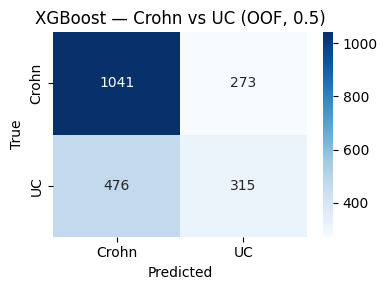

In [47]:
def plot_cm_binary(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Crohn", "UC"],
                yticklabels=["Crohn", "UC"],
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# XGBoost out-of-fold evaluation at the default 0.5 threshold (scored samples only)
mb = require_scored(res_ibd, "the binary Crohn-vs-UC CV")
if not mb.all():
    print(f"NOTE: reporting on {mb.sum()}/{len(mb)} IBD samples; "
          f"the rest were in skipped folds.\n")

y_pred_ibd = (res_ibd["oof_proba"][mb] > 0.5).astype(int)
print("XGBoost — Crohn vs UC (out-of-fold, threshold 0.5)")
print(classification_report(y_ibd[mb], y_pred_ibd, target_names=["Crohn", "UC"]))
if len(np.unique(y_ibd[mb])) == 2:
    print(f"OOF ROC-AUC: {roc_auc_score(y_ibd[mb], res_ibd['oof_proba'][mb]):.4f}")
else:
    print("OOF ROC-AUC skipped: only one class present among scored samples.")
plot_cm_binary(y_ibd[mb], y_pred_ibd, "XGBoost — Crohn vs UC (OOF, 0.5)")

Random Forest — Crohn vs UC (out-of-fold)
              precision    recall  f1-score   support

       Crohn       0.69      0.68      0.69      1314
          UC       0.48      0.50      0.49       791

    accuracy                           0.61      2105
   macro avg       0.59      0.59      0.59      2105
weighted avg       0.61      0.61      0.61      2105



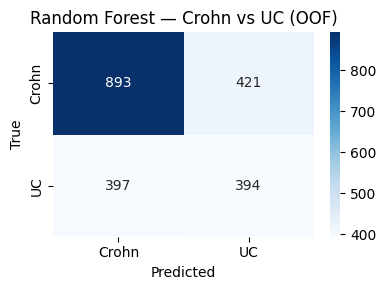

In [48]:
mb = require_scored(res_ibd, "the binary Crohn-vs-UC CV")
print("Random Forest — Crohn vs UC (out-of-fold)")
print(classification_report(y_ibd[mb], res_ibd["oof_pred_rf"][mb], target_names=["Crohn", "UC"]))
plot_cm_binary(y_ibd[mb], res_ibd["oof_pred_rf"][mb], "Random Forest — Crohn vs UC (OOF)")

Default threshold (0.5):        F1 = 0.4569
Validation-tuned per-fold:      F1 = 0.5568

Tuned-threshold out-of-fold results:
              precision    recall  f1-score   support

       Crohn       0.85      0.08      0.14      1314
          UC       0.39      0.98      0.56       791

    accuracy                           0.42      2105
   macro avg       0.62      0.53      0.35      2105
weighted avg       0.67      0.42      0.30      2105



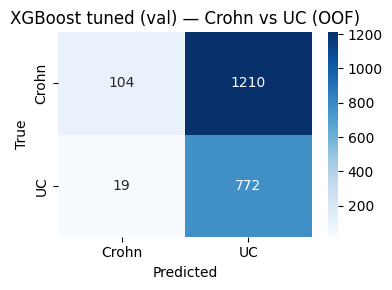

In [49]:
# Each fold's threshold was chosen on that fold's validation split and applied to its
# own held-out projects, so pooling them below reports test data exactly once.
mb = require_scored(res_ibd, "the binary Crohn-vs-UC CV")
y_pred_default = (res_ibd["oof_proba"][mb] > 0.5).astype(int)
y_pred_tuned   = (res_ibd["oof_proba"][mb] > res_ibd["oof_thr"][mb]).astype(int)

print(f"Default threshold (0.5):        F1 = {f1_score(y_ibd[mb], y_pred_default):.4f}")
print(f"Validation-tuned per-fold:      F1 = {f1_score(y_ibd[mb], y_pred_tuned):.4f}")
print("\nTuned-threshold out-of-fold results:")
print(classification_report(y_ibd[mb], y_pred_tuned, target_names=["Crohn", "UC"]))
plot_cm_binary(y_ibd[mb], y_pred_tuned, "XGBoost tuned (val) — Crohn vs UC (OOF)")

# A trade rather than an improvement: UC recall is bought with Crohn recall, and
# ROC-AUC is unchanged because moving a threshold slides along a fixed curve.

# 9) Findings & Limitations

## Headline

**The binary Crohn vs UC model is the only result worth quoting.** It reaches
out-of-fold ROC-AUC of **0.637** on a clean 2-fold geometry with 6 test projects per
fold. Accuracy of 0.64 sits **1.6 points above the 0.624 majority baseline**, so the
AUC rather than the accuracy is what carries the signal: the model ranks UC above
Crohn better than chance, while its hard predictions are close to guessing the
majority class.

**The 3-class model does not clear its own baseline.** Against a majority baseline of
**0.463**, Random Forest reaches 0.47 and XGBoost 0.44. Macro F1 is 0.44 for both.

| Model | Accuracy | Baseline | Macro F1 | Macro ROC-AUC |
|---|---|---|---|---|
| 3-class Random Forest | 0.47 | 0.463 | 0.44 | n/a |
| 3-class XGBoost | 0.44 | 0.463 | 0.44 | 0.646 |
| Binary Random Forest | 0.61 | 0.624 | 0.59 | n/a |
| Binary XGBoost | 0.64 | 0.624 | 0.60 | 0.637 |

## How unstable these numbers are

UC recall in the 3-class model moved from 0.06 to 0.60 between two runs that differed
only in fold geometry. Nothing about the model changed. With 12 cohorts, which
projects land in which fold moves the result more than any modelling decision does,
and that instability is itself the finding.

The multiclass geometry never became clean. The search reports one surviving problem:
fold 2 trains on 1032 of 2838 samples (36%) and predicts 1806 of them. Its per-fold
standard deviations should therefore be read as noise, and only the pooled
out-of-fold figures quoted. The binary geometry is clean and its numbers are sound.

## What the three interventions actually did

**Feature transforms made no difference.** Macro ROC-AUC came out at 0.705 (raw),
0.713 (log1p) and 0.684 (CLR), a spread comfortably inside the per-fold standard
deviation of roughly 0.07. Worth stating plainly because the earlier comparison was a
no-op that could not have shown a difference: tree ensembles split on thresholds and
so are invariant to any monotonic per-feature transform, and the one step that is
sensitive, LASSO selection, was being fed raw values regardless. Both paths are now
wired correctly, CLR was added precisely because it is not a per-feature monotonic
map, and the honest answer is still that none of them helps.

**Class weighting helped XGBoost slightly and Random Forest not at all.** XGBoost UC
recall rose from 0.604 to 0.651 and accuracy from 0.453 to 0.512. The Random Forest
numbers are byte-identical weighted and unweighted, which is evidence that this cuML
build silently ignores `class_weight`; the guard in Section 5 reports whether the
parameter is exposed.

**Threshold tuning is a trade, not an improvement.** Lowering the cutoff lifts UC F1
from 0.457 to 0.557 and UC recall to 0.98, while Crohn recall collapses from 0.79 to
0.08 and accuracy falls to 0.42. ROC-AUC is unchanged, because moving a threshold
slides along a fixed curve rather than improving it. Which operating point to prefer
is a clinical judgement about which misdiagnosis costs more.

## Why performance is this weak

**Twelve cohorts is the binding constraint,** and it is a count of projects rather
than samples. Two projects (PRJNA398089 and PRJNA993675) hold roughly 80% of the IBD
samples, so grouped cross-validation is effectively testing on a handful of
independent sources. Between-cohort technical variation is large relative to disease
signal, and grouping correctly refuses to reward a model for memorising it.

**Crohn and UC genuinely overlap at the species level.** These are two inflammatory
conditions in the same organ system with substantially shared dysbiosis. The 10 to
20% clinical misdiagnosis rate quoted in the problem statement is evidence the
distinction is hard with a colonoscopy, so stool composition alone separating them
cleanly was never likely.

**The single-technology merge narrows generalisation.** Every modelled sample is
shotgun metagenomics, so nothing here is tested on amplicon data.

## Future work

1. **More independent cohorts.** The genuine fix, and unavailable here. More samples
   from the existing 12 projects would not address the constraint.
2. **Batch correction.** Grouped CV prevents leakage but does not remove the
   confound. ComBat or an equivalent belongs upstream of the model.
3. **Report the binary model as the headline** and present the 3-class result with
   its baseline attached, rather than averaging the UC failure into a macro F1.
4. **Repeated cross-validation across several seeds.** Given how far one fold
   reshuffle moved UC recall, a single geometry is not enough to characterise
   performance; a distribution over seeds would be more honest than any point
   estimate.

## Status

At this level of performance this is a research exercise and not a diagnostic tool.
No result here is suitable for clinical use.